# Import packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from PIL import Image

from torchmetrics.image.fid import FrechetInceptionDistance
import os
from tqdm.notebook import tqdm
import numpy as np
from contextlib import nullcontext
import warnings
import configparser
warnings.filterwarnings('ignore')

# Config vars.

In [2]:
DEVICE= torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_EPOCHS = 20
PATIENCE_LIMIT = 5

BATCH_SIZE = 16

OPTIMIZER_LR = 2e-4

OPTIMIZER_BETAS = (0.5, 0.99)
FLATTENED_IMAGE_SHAPE = 256 * 256 * 1

IMG_RESIZED_H_W= 256

IMG_CHANNELS= 3

LAMBDA_L1= 100

# Discriminator architecture

In [3]:
# Conv block: Conv -> InstanceNorm -> LeakyReLU
class DiscConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, is_norm=True, stride=2, padding=1):
        """
        Initializes a convolutional block for the discriminator.
        
        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            is_norm (bool): Whether to include instance normalization (default: True).
            stride (int): Stride value for the convolution (default: 2).
            padding (int): Padding value for the convolution (default: 1).
        """
        super().__init__()

        layers = nn.ModuleList()

        # Convolutional layer: Applies a 2D convolution with a kernel size of 4.
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=4,
                stride=stride,
                padding=padding,
                padding_mode="reflect"  # Reflective padding to avoid artifacts at borders.
            )
        )

        # Instance normalization (optional): Normalizes feature maps.
        if is_norm:
            layers.append(
                nn.InstanceNorm2d(num_features=out_channels)
            )

        # Leaky ReLU activation: Helps with non-linearity and avoids dead neurons.
        layers.append(
            nn.LeakyReLU(0.2)  # Negative slope of 0.2 (common for GANs).
        )

        # Sequential block combining all layers.
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass through the discriminator convolutional block.

        Args:
            x (Tensor): Input tensor.

        Returns:
            Tensor: Output after passing through the conv, norm, and activation layers.
        """
        out = self.block(x)
        return out

In [4]:
# Discriminator model for a GAN
class Discriminator(nn.Module):

    def __init__(self, in_channels=3, num_features=[64, 128, 256, 512]):
        """
        Initializes the discriminator model for a GAN.
        
        Args:
            in_channels (int): Number of input channels (default: 3 for RGB).
            num_features (list): List of feature maps for each layer (default: [64, 128, 256, 512]).
        """
        super().__init__()

        in_channels = in_channels * 2  # The discriminator receives concatenated input (x and y), so 6 channels.

        layers = nn.ModuleList()

        # Build layers dynamically based on num_features
        for idx, n_feat in enumerate(num_features):
            if idx == 0:  # First layer (no normalization)
                layers.append(
                    DiscConvBlock(in_channels, n_feat, False, 2, 1)
                )
            elif idx == len(num_features) - 1:  # Last layer (with normalization)
                layers.append(
                    DiscConvBlock(in_channels, n_feat, True, 1, 1)
                )
            else:  # Intermediate layers (with normalization)
                layers.append(
                    DiscConvBlock(in_channels, n_feat, True, 2, 1)
                )

            # Update input channels for the next layer
            in_channels = n_feat

        # Final Conv layer to output a single channel (discriminator's decision)
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=1,
                kernel_size=4,
                stride=1,
                padding=1,
                padding_mode="reflect"  # Reflective padding to prevent border artifacts.
            )
        )

        # Combine all layers into the final model
        self.model = nn.Sequential(*layers)

    def forward(self, x, y):
        """
        Forward pass through the discriminator. Takes in two inputs (x and y), concatenates them, 
        and processes them through the discriminator network.
        
        Args:
            x (Tensor): Real or generated image (B, 3, 256, 256).
            y (Tensor): Mask or input corresponding to x (B, 3, 256, 256).
        
        Returns:
            Tensor: Output of the discriminator (B, 1, 30, 30), which gives the decision for each patch.
        """
        # Concatenate x and y along the channel dimension (B, 6, 256, 256)
        x = torch.cat([x, y], dim=1)

        # Pass through the model
        out = self.model(x)

        return out

In [5]:
dummy_model= Discriminator()
dummy_model= dummy_model.to(DEVICE)

x= torch.randn((BATCH_SIZE, IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W), device= DEVICE)
y= torch.randn((BATCH_SIZE, IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W), device= DEVICE)

out= dummy_model(x, y)

print(f"X shape: {x.shape}\nY shape: {y.shape}\nOUT shape: {out.shape}")

X shape: torch.Size([16, 3, 256, 256])
Y shape: torch.Size([16, 3, 256, 256])
OUT shape: torch.Size([16, 1, 30, 30])


In [6]:
from torchsummary import summary
summary(dummy_model, [(IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W),
                      (IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W)], device= DEVICE.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           6,208
         LeakyReLU-2         [-1, 64, 128, 128]               0
     DiscConvBlock-3         [-1, 64, 128, 128]               0
            Conv2d-4          [-1, 128, 64, 64]         131,200
    InstanceNorm2d-5          [-1, 128, 64, 64]               0
         LeakyReLU-6          [-1, 128, 64, 64]               0
     DiscConvBlock-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 256, 32, 32]         524,544
    InstanceNorm2d-9          [-1, 256, 32, 32]               0
        LeakyReLU-10          [-1, 256, 32, 32]               0
    DiscConvBlock-11          [-1, 256, 32, 32]               0
           Conv2d-12          [-1, 512, 31, 31]       2,097,664
   InstanceNorm2d-13          [-1, 512, 31, 31]               0
        LeakyReLU-14          [-1, 512,

# Generator architecture

In [7]:
# Generator Convolutional Block (Down and Up layers for U-Net)
class GenConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_down=True, is_relu=True, use_dropout=True, is_norm=True):
        """
        Initializes a generator convolutional block, which can be used for both downsampling and upsampling in a U-Net style generator.
        
        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            is_down (bool): If True, uses convolution for downsampling. If False, uses transposed convolution for upsampling.
            is_relu (bool): If True, uses ReLU activation. Otherwise, uses LeakyReLU.
            use_dropout (bool): If True, applies dropout to the output of the convolution.
            is_norm (bool): If True, applies instance normalization to the convolution output.
        """
        super().__init__()

        layers = nn.ModuleList()

        # Convolution Layer (Downsample or Upsample based on is_down)
        if is_down:
            # Downsampling: Regular convolution
            layers.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    padding_mode="reflect"  # Reflective padding to avoid border artifacts
                )
            )
        else:
            # Upsampling: Transposed convolution
            layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            )

        # Instance Normalization (applied if is_norm=True)
        if is_norm:
            layers.append(
                nn.InstanceNorm2d(num_features=out_channels)
            )

        # Activation Function: ReLU or LeakyReLU
        if is_relu:
            layers.append(
                nn.ReLU()
            )
        else:
            layers.append(
                nn.LeakyReLU(0.2)
            )

        # Dropout (applied if use_dropout=True)
        if use_dropout:
            layers.append(
                nn.Dropout(0.5)  # 50% dropout
            )

        # Combine all layers into the final block
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass through the generator convolutional block.
        
        Args:
            x (Tensor): Input tensor of shape (B, in_channels, H, W).
        
        Returns:
            Tensor: Output tensor after applying conv, norm, activation, and dropout (if applicable).
        """
        out = self.block(x)
        return out

In [8]:
# Generator network for image generation (e.g., for GANs)

# IP: (B, 3, 256, 256)  # Input tensor: batch size B, 3 color channels, 256x256 image
# OP: (B, 3, 256, 256)  # Output tensor: same shape as input, after generation

class Generator(nn.Module):
    def __init__(self, in_channels=3, num_features=64):
        super().__init__()

        # DOWN LAYERS (Encoder-like structure)

        ## d1 := (B, 3, 256, 256) -> (B, 64, 128, 128)
        self.down_layer_1 = GenConvBlock(
            in_channels=in_channels, 
            out_channels=num_features, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=False
        ) 

        ## d2 := (B, 64, 128, 128) -> (B, 128, 64, 64)
        self.down_layer_2 = GenConvBlock(
            in_channels=num_features, 
            out_channels=num_features*2, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        ) 
        
        ## d3 := (B, 128, 64, 64) -> (B, 256, 32, 32)
        self.down_layer_3 = GenConvBlock(
            in_channels=num_features*2, 
            out_channels=num_features*4, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        )

        ## d4 := (B, 256, 32, 32) -> (B, 512, 16, 16)
        self.down_layer_4 = GenConvBlock(
            in_channels=num_features*4, 
            out_channels=num_features*8, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        )

        ## d5 := (B, 512, 16, 16) -> (B, 512, 8, 8)
        self.down_layer_5 = GenConvBlock(
            in_channels=num_features*8, 
            out_channels=num_features*8, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        )

        ## d6 := (B, 512, 8, 8) -> (B, 512, 4, 4)
        self.down_layer_6 = GenConvBlock(
            in_channels=num_features*8, 
            out_channels=num_features*8, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        )

        ## d7 := (B, 512, 4, 4) -> (B, 512, 2, 2)
        self.down_layer_7 = GenConvBlock(
            in_channels=num_features*8, 
            out_channels=num_features*8, 
            is_down=True, 
            is_relu=False, 
            use_dropout=False, 
            is_norm=True
        )

        # BOTTLENECK: (B, 512, 2, 2) -> (B, 512, 1, 1)
        self.bottleneck = GenConvBlock(
            in_channels=num_features*8, 
            out_channels=num_features*8, 
            is_down=True, 
            is_relu=True, 
            use_dropout=False, 
            is_norm=False
        )


        # UP LAYERS (Decoder-like structure)

        ## u1 := (B, 512, 1, 1) -> (B, 512, 2, 2)
        self.up_layer_1 = GenConvBlock(
            in_channels=num_features*8, 
            out_channels=num_features*8, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u2 := (B, 512, 2, 2) + (B, 512, 2, 2) = (B, 1024, 2, 2) -> (B, 512, 4, 4)
        self.up_layer_2 = GenConvBlock(
            in_channels=num_features*8*2, 
            out_channels=num_features*8, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u3 := (B, 512, 4, 4) + (B, 512, 4, 4) = (B, 1024, 4, 4) -> (B, 512, 8, 8)
        self.up_layer_3 = GenConvBlock(
            in_channels=num_features*8*2, 
            out_channels=num_features*8, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u4 := (B, 512, 8, 8) + (B, 512, 8, 8) = (B, 1024, 8, 8) -> (B, 512, 16, 16)
        self.up_layer_4 = GenConvBlock(
            in_channels=num_features*8*2, 
            out_channels=num_features*8, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u5 := (B, 512, 16, 16) + (B, 512, 16, 16) = (B, 1024, 16, 16) -> (B, 256, 32, 32)
        self.up_layer_5 = GenConvBlock(
            in_channels=num_features*8*2, 
            out_channels=num_features*4, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u6 := (B, 256, 32, 32) + (B, 256, 32, 32) = (B, 512, 32, 32) -> (B, 128, 64, 64)
        self.up_layer_6 = GenConvBlock(
            in_channels=num_features*4*2, 
            out_channels=num_features*2, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## u7 := (B, 128, 64, 64) + (B, 128, 64, 64) = (B, 256, 64, 64) -> (B, 64, 128, 128)
        self.up_layer_7 = GenConvBlock(
            in_channels=num_features*2*2, 
            out_channels=num_features, 
            is_down=False, 
            is_relu=True, 
            use_dropout=True, 
            is_norm=True
        ) 

        ## final layer := (B, 64, 128, 128) + (B, 64, 128, 128) = (B, 128, 128, 128) -> (B, 3, 256, 256)
        self.final_layer = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=num_features*2,
                out_channels=in_channels,
                kernel_size=4, 
                stride=2,
                padding=1
            ),
            nn.Tanh()  # Use Tanh to scale the output to [-1, 1]
        )

    def forward(self, x):
        # x -> (B, 3, 256, 256)  # Input image

        # Apply down layers
        d1 = self.down_layer_1(x)  # (B, 64, 128, 128)
        d2 = self.down_layer_2(d1)  # (B, 128, 64, 64)
        d3 = self.down_layer_3(d2)  # (B, 256, 32, 32)
        d4 = self.down_layer_4(d3)  # (B, 512, 16, 16)
        d5 = self.down_layer_5(d4)  # (B, 512, 8, 8)
        d6 = self.down_layer_6(d5)  # (B, 512, 4, 4)
        d7 = self.down_layer_7(d6)  # (B, 512, 2, 2)

        # Apply bottleneck layer
        bot_neck_out = self.bottleneck(d7)  # (B, 512, 1, 1)

        # Apply up layers (decoder)
        u1 = self.up_layer_1(bot_neck_out)  # (B, 512, 2, 2)
        u2 = self.up_layer_2(torch.cat([u1, d7], dim=1))  # (B, 512, 4, 4)
        u3 = self.up_layer_3(torch.cat([u2, d6], dim=1))  # (B, 512, 8, 8)
        u4 = self.up_layer_4(torch.cat([u3, d5], dim=1))  # (B, 512, 16, 16)
        u5 = self.up_layer_5(torch.cat([u4, d4], dim=1))  # (B, 256, 32, 32)
        u6 = self.up_layer_6(torch.cat([u5, d3], dim=1))  # (B, 128, 64, 64)
        u7 = self.up_layer_7(torch.cat([u6, d2], dim=1))  # (B, 64, 128, 128)

        # Final output layer
        final_out = self.final_layer(torch.cat([u7, d1], dim=1))  # (B, 3, 256, 256)

        return final_out

In [9]:
dummy_model= Generator()
dummy_model= dummy_model.to(DEVICE)

x= torch.randn((BATCH_SIZE, IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W), device= DEVICE)

out= dummy_model(x)

print(f"X shape: {x.shape}\nOUT shape: {out.shape}")

X shape: torch.Size([16, 3, 256, 256])
OUT shape: torch.Size([16, 3, 256, 256])


In [10]:
summary(dummy_model, (IMG_CHANNELS, IMG_RESIZED_H_W, IMG_RESIZED_H_W), device= DEVICE.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           3,136
         LeakyReLU-2         [-1, 64, 128, 128]               0
      GenConvBlock-3         [-1, 64, 128, 128]               0
            Conv2d-4          [-1, 128, 64, 64]         131,200
    InstanceNorm2d-5          [-1, 128, 64, 64]               0
         LeakyReLU-6          [-1, 128, 64, 64]               0
      GenConvBlock-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 256, 32, 32]         524,544
    InstanceNorm2d-9          [-1, 256, 32, 32]               0
        LeakyReLU-10          [-1, 256, 32, 32]               0
     GenConvBlock-11          [-1, 256, 32, 32]               0
           Conv2d-12          [-1, 512, 16, 16]       2,097,664
   InstanceNorm2d-13          [-1, 512, 16, 16]               0
        LeakyReLU-14          [-1, 512,

# Dataset

In [11]:
config = configparser.ConfigParser()
config.read('config.ini')
# Load parameters from config file
#root = '/Users/leonjye/Documents/MachineLearingData'
root = config.get('DEFAULT', 'root_dir')
image_dir = os.path.join(root, 'edges2shoes','train')
image_dir

'/Users/leonjye/Documents/MachineLearingData/edges2shoes/train'

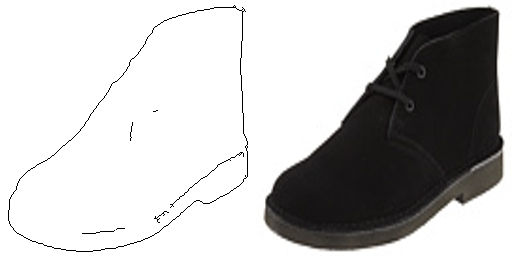

In [12]:
img= Image.open(os.path.join(image_dir, '10000_AB.jpg'))
img

In [13]:
img= np.array(img)
H, W, C= img.shape

In [14]:
edge= img[:, :int(W/2), :]
real= img[:, int(W/2):, :]

edge.shape, real.shape

((256, 256, 3), (256, 256, 3))

In [15]:
edge= Image.fromarray(edge)
real= Image.fromarray(real)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

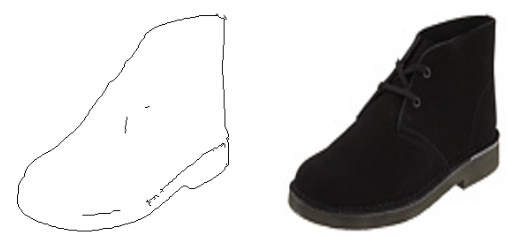

In [16]:
plt.subplot(121)
plt.imshow(edge)
plt.axis('off')

plt.subplot(122)
plt.imshow(real)
plt.axis('off')

In [17]:
# Custom Dataset for paired images (e.g., Edges ↔ Shoes)
class EdgesShoeDataset(Dataset):
    
    def __init__(self, root_dir, data_transforms):
        """
        Args:
            root_dir (str): Directory containing side-by-side paired images.
            data_transforms (callable): Transformations to apply to both halves of the image.
        """
        self.root_dir = root_dir
        self.data_transforms = data_transforms
        self.file_names = os.listdir(root_dir)  # List of image filenames in the dataset

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the image to load.
        
        Returns:
            edge_img (Tensor): Transformed left half (e.g., edge map).
            shoe_img (Tensor): Transformed right half (e.g., shoe image).
        """
        file_name = self.file_names[idx]
        img_path = os.path.join(self.root_dir, file_name)

        # Open image and ensure RGB format
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)

        H, W, C = img.shape

        # Split into left (input) and right (target) halves
        edge_img = Image.fromarray(img[:, :W//2, :])
        shoe_img = Image.fromarray(img[:, W//2:, :])

        # Apply data transforms
        if self.data_transforms:
            edge_img = self.data_transforms(edge_img)
            shoe_img = self.data_transforms(shoe_img)

        return edge_img, shoe_img


In [18]:
transform= transforms.Compose([
    transforms.Resize((IMG_RESIZED_H_W, IMG_RESIZED_H_W)),
    transforms.ToTensor()
])

train_valid_dataset= EdgesShoeDataset(
    root_dir= image_dir,
    data_transforms= transform
)

train_valid_dataset_size= len(train_valid_dataset)
train_dataset_size= int(0.8 * train_valid_dataset_size)
valid_dataset_size= train_valid_dataset_size - train_dataset_size

train_dataset, valid_dataset = random_split(train_valid_dataset, [train_dataset_size, valid_dataset_size])

In [19]:
train_loader= DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle= True, pin_memory= True)
valid_loader= DataLoader(valid_dataset, batch_size= BATCH_SIZE, shuffle= False, pin_memory= True)

In [20]:
X, y= next(iter(train_loader))
X.shape, y.shape

(torch.Size([16, 3, 256, 256]), torch.Size([16, 3, 256, 256]))

In [21]:
X, y= next(iter(valid_loader))
X.shape, y.shape

(torch.Size([16, 3, 256, 256]), torch.Size([16, 3, 256, 256]))

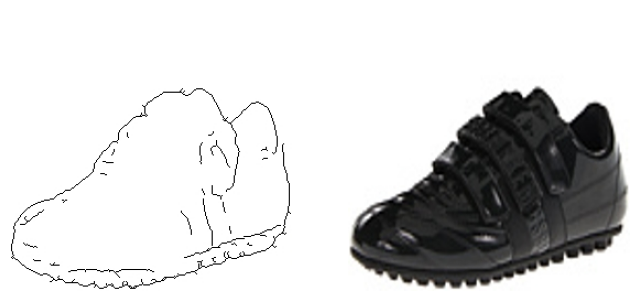

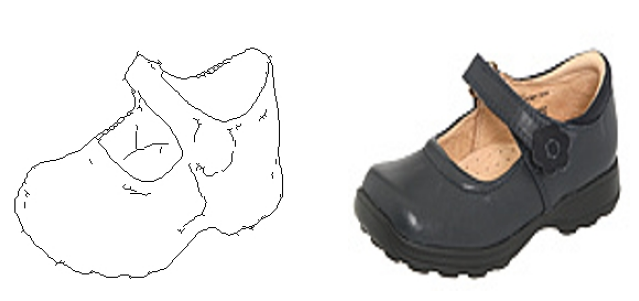

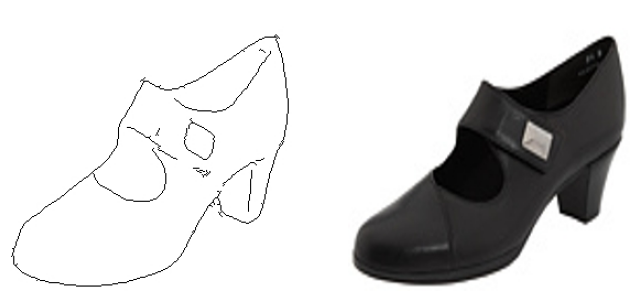

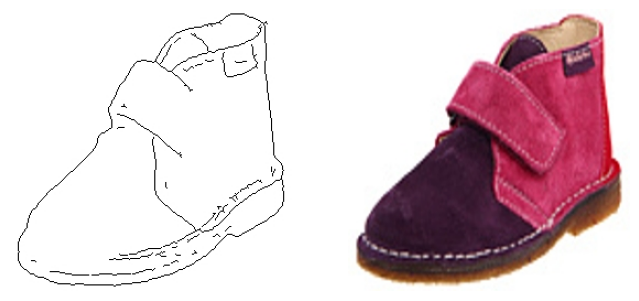

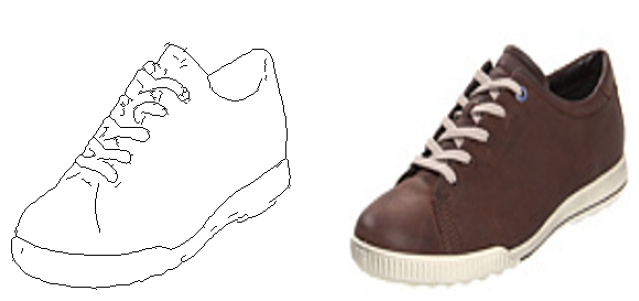

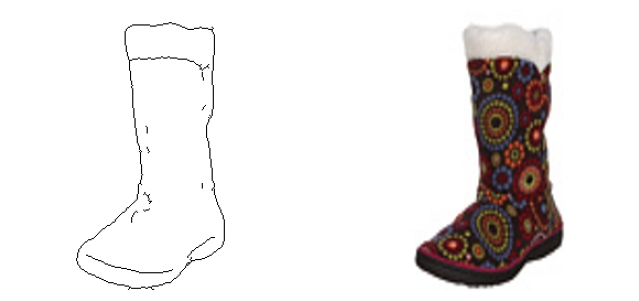

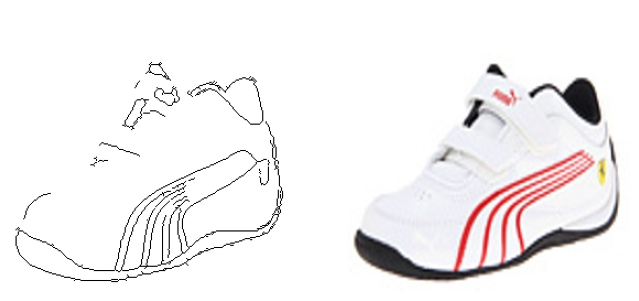

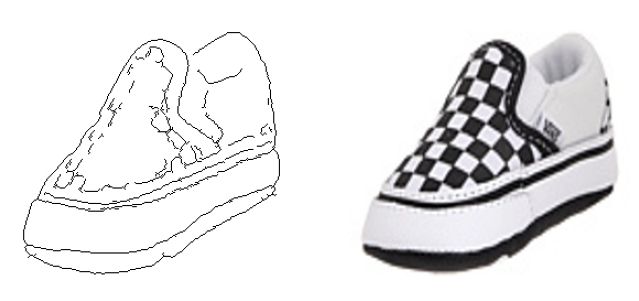

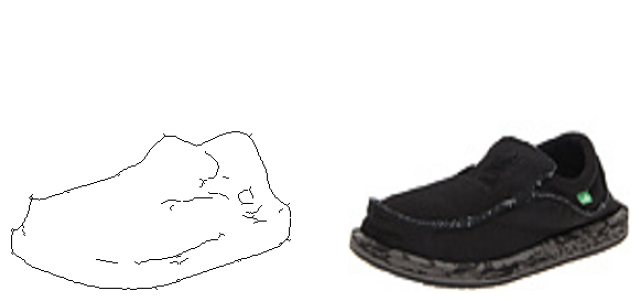

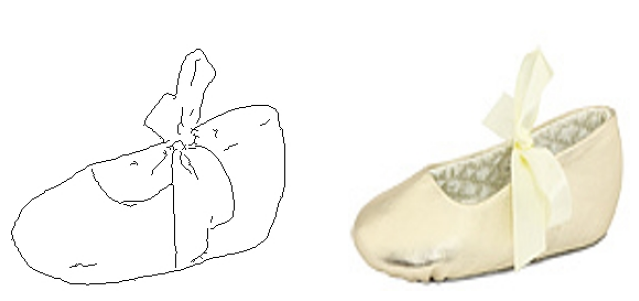

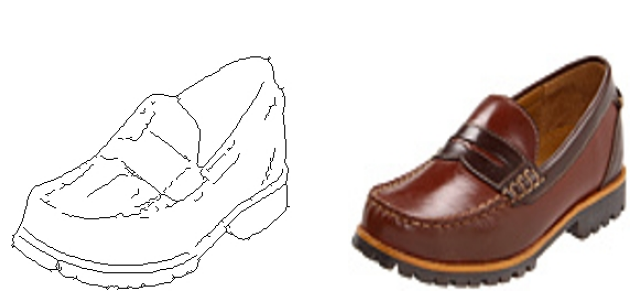

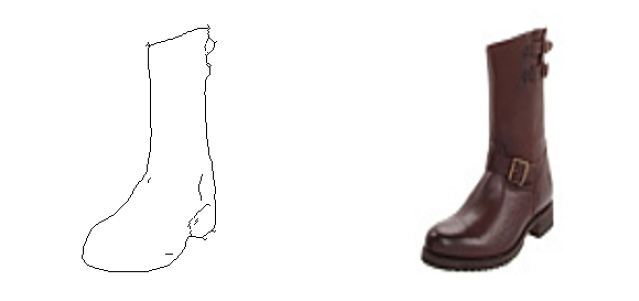

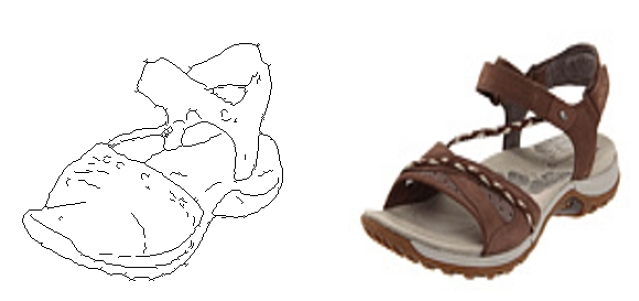

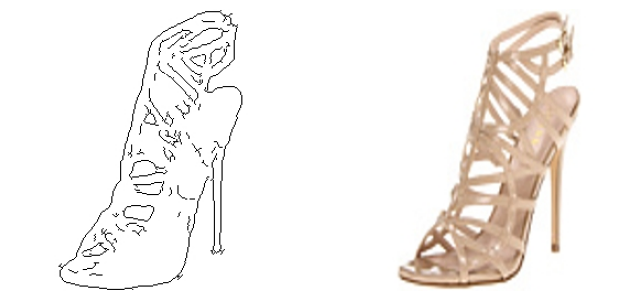

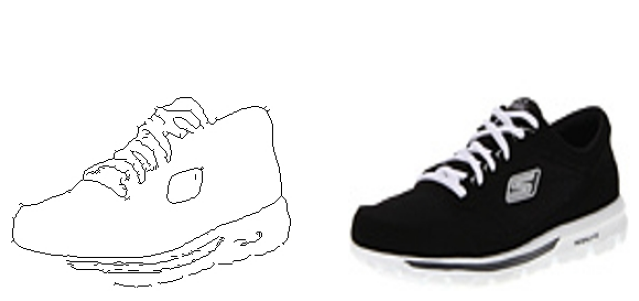

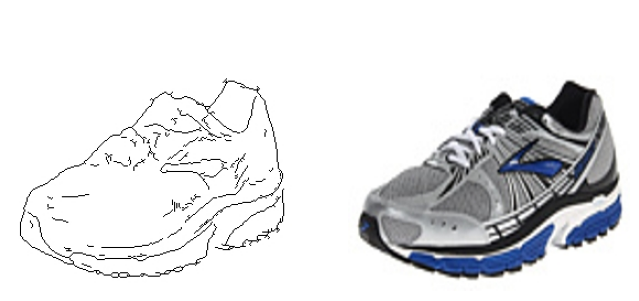

In [22]:
# show first batch of the valid loader
for i in range(16):

    plt.figure(figsize= (8, 8))

    edge_img= X[i]
    edge_img= edge_img.permute(1, 2, 0)
    
    plt.subplot(121)
    plt.imshow(edge_img)

    plt.axis('off')

    shoe_img= y[i]
    shoe_img= shoe_img.permute(1, 2, 0)
    
    plt.subplot(122)
    plt.imshow(shoe_img)

    plt.axis('off')

    plt.show()

# Model related inits.

In [23]:
# models
generator_model= Generator()
discriminator_model= Discriminator()

generator_model= generator_model.to(DEVICE)
discriminator_model= discriminator_model.to(DEVICE)

In [24]:
# optimizer
generator_optimizer= optim.Adam(params= generator_model.parameters(), lr= OPTIMIZER_LR, betas= OPTIMIZER_BETAS)
discriminator_optimizer= optim.Adam(params= discriminator_model.parameters(), lr= OPTIMIZER_LR, betas= OPTIMIZER_BETAS)

In [25]:
# loss
BCE_loss= nn.BCEWithLogitsLoss()
L1_loss= nn.L1Loss()

In [26]:
# scaler
generator_scaler = torch.amp.GradScaler("cuda")
discriminator_scaler = torch.amp.GradScaler("cuda")

In [27]:
def to_uint8(images):
    # Assume images are in [-1, 1] or [0, 1] range
    if images.min() < 0:
        images = (images + 1) / 2  # convert from [-1,1] to [0,1]

    images = images.clamp(0, 1) * 255  # scale to [0, 255]
    return images.to(torch.uint8)

In [28]:
import torch_fidelity
#https://github.com/toshas/torch-fidelity
fid = FrechetInceptionDistance(feature=64)
fid= fid.to(DEVICE)

In [29]:
# Compute FID score between real and fake images
def fid_score(real_imgs, fake_imgs):
    real_imgs = to_uint8(real_imgs)  # Convert real images to uint8
    fake_imgs = to_uint8(fake_imgs)  # Convert fake images to uint8

    fid.reset()                      # Reset FID metric
    fid.update(real_imgs, real=True) # Feed real images
    fid.update(fake_imgs, real=False) # Feed fake images

    fid_score = fid.compute().item()   # Compute FID score

    return fid_score

# Training

In [30]:
train_generator_losses= []
train_discriminator_losses= []
train_fids= []

valid_generator_losses= []
valid_discriminator_losses= []
valid_fids= []

In [31]:
best_epoch= 0
no_improve_epochs= 0

min_valid_fid_score= float('inf')

generator_model_best_weights_path= "edge2show_generator_best_weights.pth"
discriminator_model_best_weights_path= "edge2show_discriminator_best_weights.pth"

**Model training:-**

* PHASE 1: Training
* PHASE 2: Validation
* PHASE 3: Show images
* PHASE 4: Early stopping
* PHASE 5: Last epoch handling

In [32]:
# Training/Validation loop for Generator and Discriminator
def model_train_and_validation_phase(curr_epoch, tot_epochs,
                                     generator_model, discriminator_model,
                                     data_loader, is_train,
                                     bce_loss, l1_loss,
                                     generator_optimizer, discriminator_optimizer,
                                     generator_scaler, discriminator_scaler):
    
    # Set model to training or evaluation mode
    generator_model.train() if is_train else generator_model.eval()
    discriminator_model.train() if is_train else discriminator_model.eval()

    # Track total loss and FID across all batches
    total_generator_loss = 0
    total_discriminator_loss = 0
    total_fid = 0

    # Disable gradient computation in validation to save memory and speed up
    gradient_context = nullcontext() if is_train else torch.no_grad()

    with gradient_context:
        for batch_edges, batch_shoes in tqdm(data_loader):  
            # Move data to GPU
            batch_edges = batch_edges.to(DEVICE)
            batch_shoes = batch_shoes.to(DEVICE)

            # Forward pass: generate fake output images from edge input
            fake_shoes = generator_model(batch_edges)

            # -------------------------
            # Train Discriminator (real vs fake)
            # -------------------------
            with torch.amp.autocast("cuda"):  # Mixed precision for speed
                # Discriminator predictions
                D_real = discriminator_model(batch_edges, batch_shoes)         # Real pair
                D_fake = discriminator_model(batch_edges, fake_shoes.detach()) # Fake pair (detach so G isn't updated here)

                # Real should be classified as 1, fake as 0
                D_real_loss = bce_loss(D_real, torch.ones_like(D_real))
                D_fake_loss = bce_loss(D_fake, torch.zeros_like(D_fake))

                # Final discriminator loss (mean of real and fake)
                D_loss = (D_real_loss + D_fake_loss) / 2

            total_discriminator_loss += D_loss.item()

            if is_train:
                # Backprop & update discriminator
                nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
                discriminator_optimizer.zero_grad()
                discriminator_scaler.scale(D_loss).backward()
                discriminator_scaler.step(discriminator_optimizer)
                discriminator_scaler.update()

            # -------------------------
            # Train Generator (try to fool D + match GT)
            # -------------------------
            with torch.amp.autocast("cuda"):
                # Re-evaluate D on fake output (now generator's turn)
                D_fake = discriminator_model(batch_edges, fake_shoes)

                # Try to fool the discriminator (wants D_fake → 1)
                G_bce_loss = bce_loss(D_fake, torch.ones_like(D_fake))

                # L1 loss = pixel-wise similarity to ground truth
                G_l1_loss = l1_loss(fake_shoes, batch_shoes)

                # Total generator loss = adversarial + reconstruction loss
                G_loss = G_bce_loss + (LAMBDA_L1 * G_l1_loss)

            total_generator_loss += G_loss.item()

            # Evaluate generator quality using FID (Fréchet Inception Distance)
            fid = fid_score(batch_shoes, fake_shoes)
            total_fid += fid

            if is_train:
                # Backprop & update generator
                nn.utils.clip_grad_norm_(generator_model.parameters(), max_norm=1.0)
                generator_optimizer.zero_grad()
                generator_scaler.scale(G_loss).backward()
                generator_scaler.step(generator_optimizer)
                generator_scaler.update()

    # Average loss and FID per batch
    avg_generator_loss = total_generator_loss / len(data_loader)
    avg_discriminator_loss = total_discriminator_loss / len(data_loader)
    avg_fid = total_fid / len(data_loader)

    return avg_generator_loss, avg_discriminator_loss, avg_fid


In [33]:
def show_generated_images(generator_model, edges_imgs):
    # Display generated images
    generator_model.eval()

    edges_imgs= edges_imgs.to(DEVICE)
    
    fake_shoes = generator_model(edges_imgs)  # (16, 3, 256, 256)
    fake_shoes= fake_shoes.to(DEVICE)
    
    print("\n")
    plt.figure(figsize=(10, 10))
    
    for i in range(16):
      image = fake_shoes[i].permute(1, 2, 0).cpu().detach().numpy()  
      plt.subplot(4, 4, i + 1)
      plt.imshow(image)
      plt.axis('off')
    
    plt.show()
    plt.close('all')
    print("\n")

In [ ]:
# Main training-validation loop
for epoch in range(NUM_EPOCHS):
    print(f"\n\nRunning epoch [{epoch + 1}/{NUM_EPOCHS}]:- \n")

    # ------------------------------
    # PHASE 1: TRAINING
    # ------------------------------
    avg_generator_loss, avg_discriminator_loss, avg_fid = model_train_and_validation_phase(
        curr_epoch=epoch,
        tot_epochs=NUM_EPOCHS,
        generator_model=generator_model,
        discriminator_model=discriminator_model,
        data_loader=train_loader,
        is_train=True,  # Enable gradient updates
        bce_loss=BCE_loss,
        l1_loss=L1_loss,
        generator_optimizer=generator_optimizer,
        discriminator_optimizer=discriminator_optimizer,
        generator_scaler=generator_scaler,
        discriminator_scaler=discriminator_scaler
    )

    # Save training losses and FID
    train_generator_losses.append(avg_generator_loss)
    train_discriminator_losses.append(avg_discriminator_loss)
    train_fids.append(avg_fid)

    print(f"\n\n(TRAIN) Generator loss: {avg_generator_loss}")
    print(f"(TRAIN) Discriminator loss: {avg_discriminator_loss}")
    print(f"(TRAIN) FID: {avg_fid}")

    # ------------------------------
    # PHASE 2: VALIDATION
    # ------------------------------
    avg_generator_loss, avg_discriminator_loss, avg_fid = model_train_and_validation_phase(
        curr_epoch=epoch,
        tot_epochs=NUM_EPOCHS,
        generator_model=generator_model,
        discriminator_model=discriminator_model,
        data_loader=valid_loader,
        is_train=False,  # No gradient updates
        bce_loss=BCE_loss,
        l1_loss=L1_loss,
        generator_optimizer=generator_optimizer,
        discriminator_optimizer=discriminator_optimizer,
        generator_scaler=generator_scaler,
        discriminator_scaler=discriminator_scaler
    )

    # Save validation losses and FID
    valid_generator_losses.append(avg_generator_loss)
    valid_discriminator_losses.append(avg_discriminator_loss)
    valid_fids.append(avg_fid)

    print(f"\n(VALID) Generator loss: {avg_generator_loss}")
    print(f"(VALID) Discriminator loss: {avg_discriminator_loss}")
    print(f"(VALID) FID: {avg_fid}")

    # ------------------------------
    # PHASE 3: VISUALIZATION
    # ------------------------------
    edges_imgs, _ = next(iter(valid_loader))  # Sample some edge inputs
    show_generated_images(generator_model=generator_model, edges_imgs=edges_imgs)

    # ------------------------------
    # PHASE 4: EARLY STOPPING
    # ------------------------------
    if avg_fid < min_valid_fid_score:
        # Improvement found, update best epoch and save models
        no_improve_epochs = 0
        min_valid_fid_score = avg_fid
        best_epoch = epoch

        torch.save(generator_model.state_dict(), generator_model_best_weights_path)
        torch.save(discriminator_model.state_dict(), discriminator_model_best_weights_path)

    else:
        # No improvement, increase patience counter
        no_improve_epochs += 1

        if no_improve_epochs >= PATIENCE_LIMIT:
            # Restore best weights and stop training early
            generator_model = Generator().to(DEVICE)
            generator_model.load_state_dict(torch.load(generator_model_best_weights_path))

            discriminator_model = Discriminator().to(DEVICE)
            discriminator_model.load_state_dict(torch.load(discriminator_model_best_weights_path))

            print(f"\n\nEarly stopping applied at epoch {epoch}..")
            print(f"Restored best weights from epoch {best_epoch} with validation FID: {min_valid_fid_score}")
            break

    # ------------------------------
    # PHASE 5: FINAL EPOCH CHECK
    # ------------------------------
    if (epoch + 1 == NUM_EPOCHS):  # Last epoch
        # Reload the best-performing weights at the end
        generator_model = Generator().to(DEVICE)
        generator_model.load_state_dict(torch.load(generator_model_best_weights_path))

        discriminator_model = Discriminator().to(DEVICE)
        discriminator_model.load_state_dict(torch.load(discriminator_model_best_weights_path))

        print(f"\n\nTraining loop ended...")
        print(f"Restored best weights from epoch {best_epoch} with validation FID: {min_valid_fid_score}")




Running epoch [1/20]:- 



  0%|          | 0/2492 [00:00<?, ?it/s]

# Plot train and validation tracking metrics

In [2]:
# plot train and valid Generator loss
import matplotlib.pyplot as plt
plt.figure(figsize= (8, 6))
plt.plot(range(1, len(train_generator_losses)+1), train_generator_losses, color= 'orange', label= 'Train Generator loss')
plt.plot(range(1, len(valid_generator_losses)+1), valid_generator_losses, color= 'green', label= 'Valid Generator loss')
plt.xlabel('Epochs')
plt.ylabel('Generator Loss')
plt.title('Generator Loss vs Epochs')
plt.legend();

NameError: name 'train_generator_losses' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# plot train and valid Discriminator loss

plt.figure(figsize= (8, 6))
plt.plot(range(1, len(train_discriminator_losses)+1), train_discriminator_losses, color= 'orange', label= 'Train Discriminator loss')
plt.plot(range(1, len(valid_discriminator_losses)+1), valid_discriminator_losses, color= 'green', label= 'Valid Discriminator loss')
plt.xlabel('Epochs')
plt.ylabel('Discriminator Loss')
plt.title('Discriminator Loss vs Epochs')
plt.legend();

In [ ]:
# plot train and valid FID

plt.figure(figsize= (8, 6))
plt.plot(range(1, len(train_fids) +1), train_fids, color= 'orange', label= 'Train FID')
plt.plot(range(1, len(valid_fids)+1), valid_fids, color= 'green', label= 'Valid FID')
plt.xlabel('Epochs')
plt.ylabel('FID Score')
plt.title('FID Score vs Epochs')
plt.legend();

# Model generations

In [ ]:
batch_edges, batch_shoes= next(iter(valid_loader)) # (16, 3, 256, 256)
batch_edges= batch_edges.to(DEVICE)
batch_shoes= batch_shoes.to(DEVICE)

batch_edges.shape

In [ ]:
generator_model.eval()

fake_shoes = generator_model(batch_edges)


for i in range(16):
    plt.figure(figsize=(10, 10))

    plt.subplot(131)
    image = batch_edges[i].permute(1, 2, 0).cpu().detach().numpy() 
    plt.imshow(image)
    plt.axis('off')
    plt.title("edge")

    plt.subplot(132)
    image = batch_shoes[i].permute(1, 2, 0).cpu().detach().numpy() 
    plt.imshow(image)
    plt.axis('off')
    plt.title("Real shoe")

    plt.subplot(133)
    image = fake_shoes[i].permute(1, 2, 0).cpu().detach().numpy() 
    plt.imshow(image)
    plt.axis('off')
    plt.title("Generated shoe")
